# Gleichgewichts-CH₄-Umsatz (Reforming) — Funktion von T und p
Steam Reforming of Methane (SMR): CH₄ + H₂O → 1 CO + 3 H

Dry Reforming of Methane (DRM): CH₄ + CO₂ → 2 CO + 2 H₂ 
 
Berechnung mit **Cantera** (GRI30-Mechanismus)

## 1. Bibliotheken importieren

In [37]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import scipy
print(scipy.__version__)

# Schöne Plots im Notebook anzeigen
%matplotlib inline
matplotlib.rcParams.update({'font.size': 11})

print(f"Cantera Version: {ct.__version__}")

1.17.1
Cantera Version: 3.2.0


## 2. Einstellungen (Feed, Temperatur- & Druckbereich)

In [38]:
# --- Feed: CH4 + CO2 (Dry Reforming) ---
# Spezies-Reihenfolge: H2, N2, CO, CO2, CH4, C2H6, H2O, O2
#                      0    1   2   3    4    5     6    7
N_in = np.array([0, 1, 0, 0, 1.25, 0, 2.5, 0.25])
x_in = N_in / N_in.sum()   # Molenbrüche (normiert)

species_names = ['H2', 'N2', 'CO', 'CO2', 'CH4', 'C2H6', 'H2O', 'O2']
X_dict = {sp: xi for sp, xi in zip(species_names, x_in)}
print("Einsatzzusammensetzung (Molenbrüche):", X_dict)

# --- Temperaturbereich ---
T_in   = 273.15   # K
T_end  = 1600.0   # K
dT     = 20.0     # K
T_range = np.arange(T_in, T_end + dT, dT)   # in K
nT = len(T_range)

# --- Druckbereich: 1 bar, 5 bar, 10 bar dann 20, 40, ...---
p_end = 200      # bar
p_bar_vals = np.concatenate(([1, 5, 10], np.arange(20, p_end+1, 20)))   # in bar
p_vec      = p_bar_vals * 1e5                                # in Pa
np_        = len(p_vec)                                      # Anzahl Druckpunkte (= 21)

print(f"Temperaturbereich: {T_range[0]-273.15:.0f} – {T_range[-1]-273.15:.0f} °C  ({nT} Punkte)")
print(f"Druckbereich:      {p_vec[0]/1e5:.1f} – {p_vec[-1]/1e5:.1f} bar  ({np_} Punkte)")

Einsatzzusammensetzung (Molenbrüche): {'H2': np.float64(0.0), 'N2': np.float64(0.2), 'CO': np.float64(0.0), 'CO2': np.float64(0.0), 'CH4': np.float64(0.25), 'C2H6': np.float64(0.0), 'H2O': np.float64(0.5), 'O2': np.float64(0.05)}
Temperaturbereich: 0 – 1340 °C  (68 Punkte)
Druckbereich:      1.0 – 200.0 bar  (13 Punkte)


## 3. Cantera-Gasobjekt initialisieren

In [39]:
g = ct.Solution('gri30.yaml')

# Anfangszustand setzen
g.TPX = T_range[0], p_vec[0], X_dict

# Eingangs-Massenanteil CH4 speichern (Referenz für Umsatzberechnung)
w_CH4_in = g['CH4'].Y[0]
print(f"Eingangs-Massenanteil CH4: {w_CH4_in:.4f}")

Eingangs-Massenanteil CH4: 0.1983


## 4. Gleichgewichtsumsatz (Annahme: ideales Gas, Cantera behandelt mit GRI30 die Gasphase als ideales Gasgemisch)

In [40]:
# --- Gleichgewichtsberechnung — 2D über (p, T) ---
Xconv = np.full((np_, nT), np.nan) # Ergebnismatrix vorbelegen

for ip, p_now in enumerate(p_vec): # Schleife über p und T für jeweilige Conversion
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict   # Zustand setzen
            g.equilibrate('TP')            # Gleichgewicht bei (T, p)

            w_CH4 = g['CH4'].Y[0]
            umsatz = (w_CH4_in - w_CH4) / w_CH4_in
            Xconv[ip, it] = np.clip(umsatz, 0.0, 1.0)   # auf [0,1] begrenzen
        except Exception:
            Xconv[ip, it] = np.nan   # bei extremen Bedingungen

print("Berechnung abgeschlossen ✓")
print(f"  Min. Umsatz: {np.nanmin(Xconv):.3f}")
print(f"  Max. Umsatz: {np.nanmax(Xconv):.3f}")

Berechnung abgeschlossen ✓
  Min. Umsatz: 0.100
  Max. Umsatz: 1.000


Berechnung abgeschlossen ✓
  Min. Umsatz: 0.100
  Max. Umsatz: 1.000


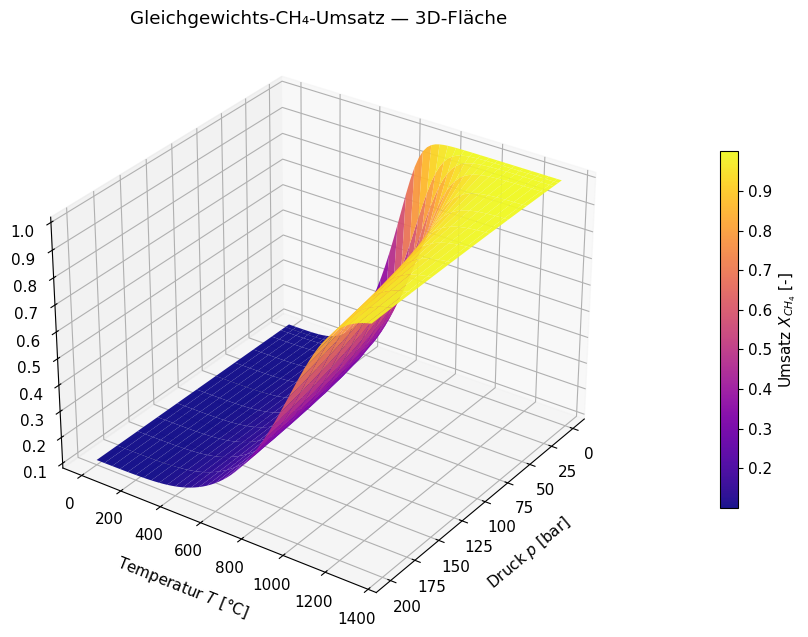

Plot gespeichert: CH4_conv_Tp_surface.pdf


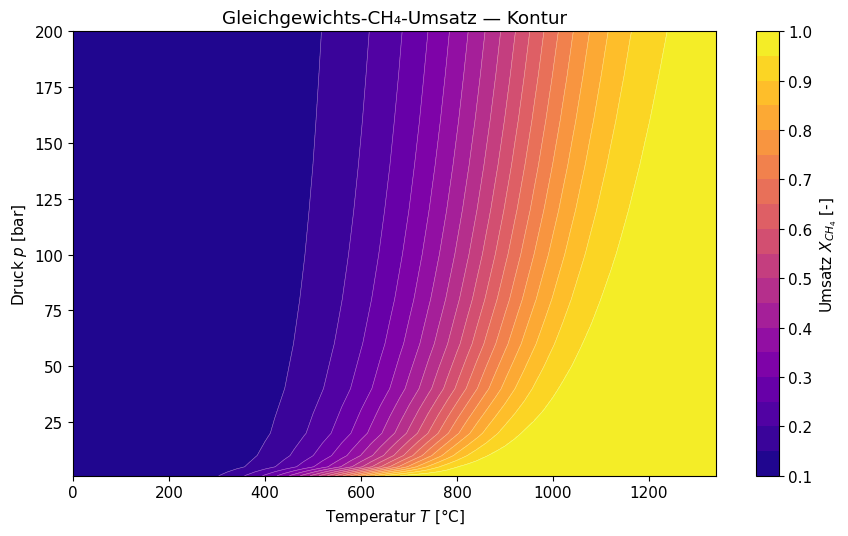

Plot gespeichert: CH4_conv_Tp_contour.pdf


In [41]:
# --- Gleichgewichtsberechnung — 2D über (p, T) ---
Xconv = np.full((np_, nT), np.nan) # Ergebnismatrix vorbelegen

for ip, p_now in enumerate(p_vec): # Schleife über p und T für jeweilige Conversion
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict   # Zustand setzen
            g.equilibrate('TP')            # Gleichgewicht bei (T, p)

            w_CH4 = g['CH4'].Y[0]
            umsatz = (w_CH4_in - w_CH4) / w_CH4_in
            Xconv[ip, it] = np.clip(umsatz, 0.0, 1.0)   # auf [0,1] begrenzen
        except Exception:
            Xconv[ip, it] = np.nan   # bei extremen Bedingungen

print("Berechnung abgeschlossen ✓")
print(f"  Min. Umsatz: {np.nanmin(Xconv):.3f}")
print(f"  Max. Umsatz: {np.nanmax(Xconv):.3f}")


# --- Gitterkoordinaten für Plots ---
T_C   = T_range - 273.15     # Kelvin → °C
p_bar = p_vec / 1e5          # Pa → bar

T_grid, P_grid = np.meshgrid(T_C, p_bar)


# --- 3D-Oberflächenplot der Reaktionsenthalpie ---
fig1, ax1 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf = ax1.plot_surface(P_grid.T, T_grid.T, Xconv.T,
                        cmap='plasma', edgecolor='none', alpha=0.95)

ax1.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax1.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax1.set_zlabel('Umsatz $X_{CH_4}$ [-]', labelpad=10)
ax1.set_title('Gleichgewichts-CH₄-Umsatz — 3D-Fläche')
ax1.view_init(elev=30, azim=35)

cbar1 = fig1.colorbar(surf, ax=ax1, pad=0.12, shrink=0.6)
cbar1.set_label('Umsatz $X_{CH_4}$ [-]')

plt.tight_layout()
fig1.savefig('CH4_conv_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: CH4_conv_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

cf = ax2.contourf(T_grid, P_grid, Xconv, levels=18, cmap='plasma')
cs = ax2.contour( T_grid, P_grid, Xconv, levels=18, colors='white', linewidths=0.4, alpha=0.5)

ax2.set_xlabel('Temperatur $T$ [°C]')
ax2.set_ylabel('Druck $p$ [bar]')
ax2.set_title('Gleichgewichts-CH₄-Umsatz — Kontur')

cbar2 = fig2.colorbar(cf, ax=ax2)
cbar2.set_label('Umsatz $X_{CH_4}$ [-]')

plt.tight_layout()
fig2.savefig('CH4_conv_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: CH4_conv_Tp_contour.pdf")

## 5. Reaktionsenthalpie (Annahme: ideales Gas, Cantera behandelt mit GRI30 die Gasphase als ideales Gasgemisch)

Berechnung abgeschlossen ✓
  Min ΔH:   -80.3 kJ/mol
  Max ΔH:   120.8 kJ/mol


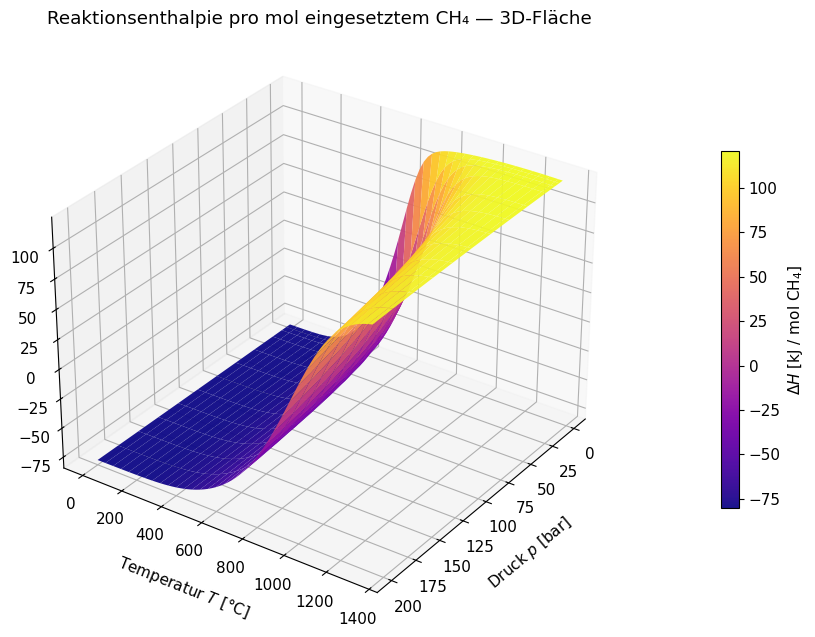

Plot gespeichert: Reaktionsenthalpie_Tp_surface.pdf


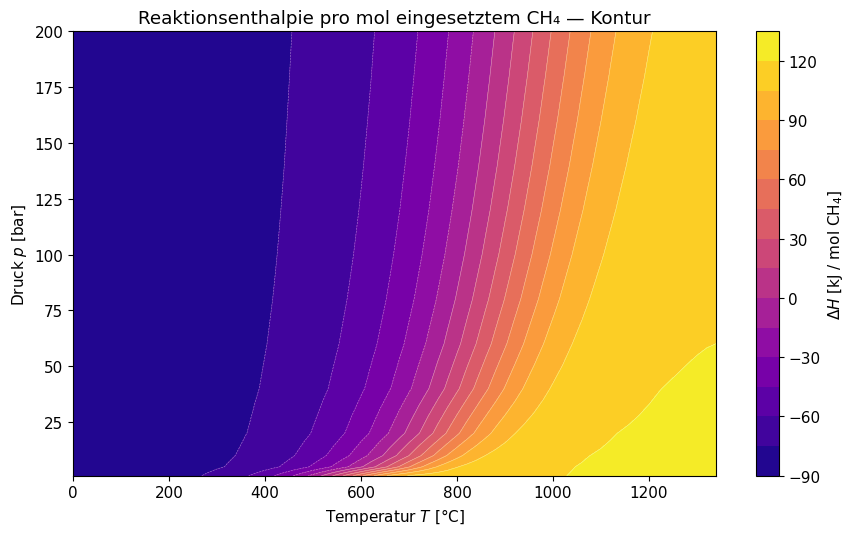

Plot gespeichert: Reaktionsenthalpie_Tp_contour.pdf

Reaktionsenthalpie ΔH [kJ / mol CH₄ eingesetzt]
                     0   100   200   300   400   500   600    700    800  \
p [bar] \ T [°C]                                                           
1.0              -80.3 -80.1 -78.8 -71.7 -51.2  -9.9  57.1  105.8  115.6   
5.0              -80.3 -80.1 -79.5 -76.1 -65.4 -42.7  -1.7   58.9  104.3   
10.0             -80.3 -80.1 -79.7 -77.2 -69.2 -52.0 -20.7   30.1   85.4   
20.0             -80.3 -80.1 -79.8 -78.0 -72.1 -59.2 -35.4    4.2   57.5   
40.0             -80.3 -80.1 -79.8 -78.5 -74.3 -64.6 -46.8  -16.8   27.7   
60.0             -80.3 -80.1 -79.9 -78.8 -75.2 -67.1 -52.1  -26.8   11.7   
80.0             -80.3 -80.1 -79.9 -78.9 -75.8 -68.7 -55.4  -33.0    1.5   
100.0            -80.3 -80.1 -79.9 -79.0 -76.2 -69.7 -57.7  -37.4   -5.9   
120.0            -80.3 -80.1 -79.9 -79.1 -76.5 -70.5 -59.4  -40.6  -11.5   
140.0            -80.3 -80.1 -79.9 -79.2 -76.8 -71.2 -60.7  -43

In [42]:
# --- Reaktionsenthalpie pro mol eingesetztem CH₄ — 2D über (p, T) ---
# Hinweis: intern wird massenbezogen gerechnet (Masse bleibt erhalten, Stoffmenge nicht!) und am Ende über M_CH4 in mol-Basis umgerechnet.

M_CH4 = 0.01604  # kg/mol

delta_H_mol = np.full((np_, nT), np.nan)   # J / mol CH4 eingesetzt

for ip, p_now in enumerate(p_vec):
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict
            w_CH4_feed = g['CH4'].Y[0]       # kg CH4 / kg Feed
            h_ein = g.enthalpy_mass          # J/kg Feed

            g.equilibrate('TP')
            h_aus = g.enthalpy_mass          # J/kg Produkt

            # (J/kg Feed) · (kg/mol CH4) / (kg CH4/kg Feed)  →  J/mol CH4
            delta_H_mol[ip, it] = (h_aus - h_ein) * M_CH4 / w_CH4_feed
        except Exception:
            pass


# Umrechnung auf kJ/mol für Plot & Tabelle
delta_H_kJmol = delta_H_mol / 1e3

print("Berechnung abgeschlossen ✓")
print(f"  Min ΔH: {np.nanmin(delta_H_kJmol):7.1f} kJ/mol")
print(f"  Max ΔH: {np.nanmax(delta_H_kJmol):7.1f} kJ/mol")


# --- 3D-Oberflächenplot der Reaktionsenthalpie ---
fig4, ax5 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf = ax5.plot_surface(P_grid.T, T_grid.T, delta_H_kJmol.T,
                        cmap='plasma', edgecolor='none', alpha=0.95)

ax5.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax5.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax5.set_zlabel(r'$\Delta H$ [kJ / mol CH$_4$]', labelpad=10)
ax5.set_title('Reaktionsenthalpie pro mol eingesetztem CH₄ — 3D-Fläche')
ax5.view_init(elev=30, azim=35)

cbar4 = fig4.colorbar(surf, ax=ax5, pad=0.12, shrink=0.6)
cbar4.set_label(r'$\Delta H$ [kJ / mol CH$_4$]')

plt.tight_layout()
fig4.savefig('Reaktionsenthalpie_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Reaktionsenthalpie_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig3, ax3 = plt.subplots(figsize=(9, 5.5))

cf = ax3.contourf(T_grid, P_grid, delta_H_kJmol, levels=18, cmap='plasma')
cs = ax3.contour( T_grid, P_grid, delta_H_kJmol, levels=18,
                  colors='white', linewidths=0.4, alpha=0.5)

ax3.set_xlabel('Temperatur $T$ [°C]')
ax3.set_ylabel('Druck $p$ [bar]')
ax3.set_title('Reaktionsenthalpie pro mol eingesetztem CH₄ — Kontur')

cbar3 = fig3.colorbar(cf, ax=ax3)
cbar3.set_label(r'$\Delta H$ [kJ / mol CH$_4$]')

plt.tight_layout()
fig3.savefig('Reaktionsenthalpie_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Reaktionsenthalpie_Tp_contour.pdf")


# --- Tabelle der zugrundeliegenden Werte ---
df_H = pd.DataFrame(
    delta_H_kJmol,
    index   = [f"{p:.1f}" for p in p_bar],
    columns = [f"{T:.0f}" for T in T_C],
)
df_H.index.name = "p [bar] \\ T [°C]"

# Konsole: kompakter Überblick (jede 5. Temperaturspalte)
print("\nReaktionsenthalpie ΔH [kJ / mol CH₄ eingesetzt]")
print("=" * 72)
print(df_H.iloc[:, ::5].round(1))

Berechnung Δcp abgeschlossen ✓
  Δcp min: -0.0020 J/(mol CH₄ · K)
  Δcp max:  0.0033 J/(mol CH₄ · K)


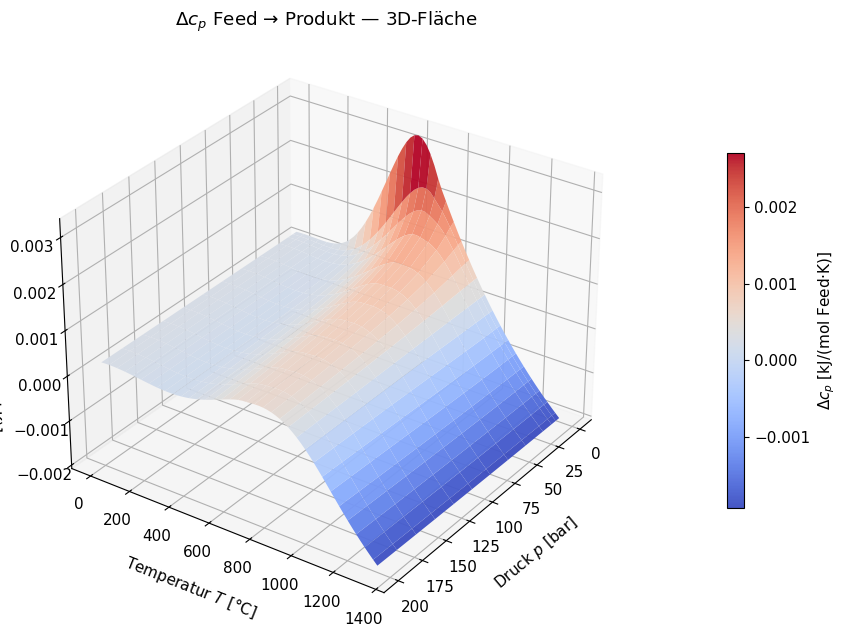

Plot gespeichert: Delta_cp_Tp_surface.pdf


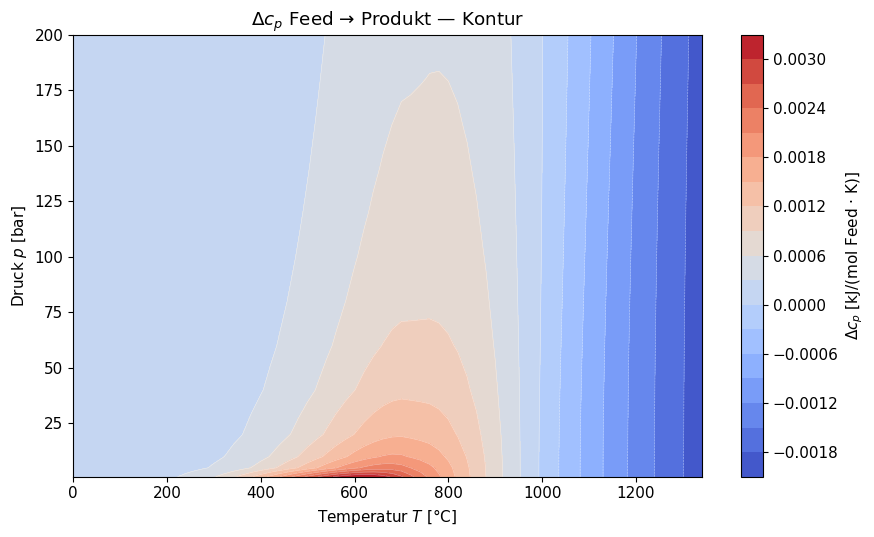

Plot gespeichert: Delta_cp_Tp_contour.pdf

Δcp [kJ / (mol Feed · K)]
                       0     100     200     300     400     500     600  \
p [bar] \ T [°C]                                                           
1.0               0.0002  0.0002  0.0003  0.0006  0.0014  0.0025  0.0033   
5.0               0.0002  0.0002  0.0002  0.0003  0.0007  0.0014  0.0020   
10.0              0.0002  0.0002  0.0002  0.0003  0.0005  0.0010  0.0016   
20.0              0.0002  0.0002  0.0002  0.0002  0.0004  0.0008  0.0012   
40.0              0.0002  0.0002  0.0002  0.0002  0.0003  0.0005  0.0009   
60.0              0.0002  0.0002  0.0002  0.0002  0.0002  0.0004  0.0007   
80.0              0.0002  0.0002  0.0002  0.0002  0.0002  0.0004  0.0007   
100.0             0.0002  0.0002  0.0002  0.0002  0.0002  0.0003  0.0006   
120.0             0.0002  0.0002  0.0002  0.0001  0.0002  0.0003  0.0005   
140.0             0.0002  0.0002  0.0002  0.0001  0.0002  0.0003  0.0005   
160.0             0

In [43]:
# --- Δcp — 2D über (p, T) ---
# cp_feed:    cp des Feeds bei (T,p) — Zusammensetzung fest = X_dict
# cp_produkt: cp des Gleichgewichts-Produktes bei gleichem (T,p)

M_CH4 = 0.01604  # kg/mol

cp_feed      = np.full((np_, nT), np.nan)   # J/(kg Feed · K)
cp_produkt   = np.full((np_, nT), np.nan)   # J/(kg Produkt · K)
delta_cp_mol = np.full((np_, nT), np.nan)   # J/(mol eingesetzt · K)

for ip, p_now in enumerate(p_vec):
    for it, T_now in enumerate(T_range):
        try:
            # Feed-Zustand
            g.TPX = T_now, p_now, X_dict
            cp_in  = g.cp_mass
            M_feed = g.mean_molecular_weight    # kg/kmol — hier abgreifen, solange Feed gesetzt!

            # Gleichgewichts-Zustand
            g.equilibrate('TP')
            cp_out = g.cp_mass

            cp_feed[ip, it]     = cp_in # J/(kg·K)
            cp_produkt[ip, it]  = cp_out # J/(kg·K)
            delta_cp_mol[ip, it] = (cp_out - cp_in)/1000 * (M_feed)/1000 # kJ/(mol Feed·K)
        except Exception:
            pass

print("Berechnung Δcp abgeschlossen ✓")
print(f"  Δcp min: {np.nanmin(delta_cp_mol):7.4f} J/(mol CH₄ · K)")
print(f"  Δcp max: {np.nanmax(delta_cp_mol):7.4f} J/(mol CH₄ · K)")


# --- 3D-Oberflächenplot ---
fig6, ax6 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf6 = ax6.plot_surface(P_grid.T, T_grid.T, delta_cp_mol.T,
                         cmap='coolwarm', edgecolor='none', alpha=0.95)

ax6.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax6.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax6.set_zlabel(r'$\Delta c_p$ [kJ/(mol Feed·K)]', labelpad=10)
ax6.set_title(r'$\Delta c_p$ Feed → Produkt — 3D-Fläche')
ax6.view_init(elev=30, azim=35)

cbar6 = fig6.colorbar(surf6, ax=ax6, pad=0.12, shrink=0.6)
cbar6.set_label(r'$\Delta c_p$ [kJ/(mol Feed·K)]')

plt.tight_layout()
fig6.savefig('Delta_cp_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Delta_cp_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig5, ax5 = plt.subplots(figsize=(9, 5.5))

cf = ax5.contourf(T_grid, P_grid, delta_cp_mol, levels=18, cmap='coolwarm')
cs = ax5.contour( T_grid, P_grid, delta_cp_mol, levels=18,
                  colors='white', linewidths=0.4, alpha=0.5)

ax5.set_xlabel('Temperatur $T$ [°C]')
ax5.set_ylabel('Druck $p$ [bar]')
ax5.set_title(r'$\Delta c_p$ Feed → Produkt — Kontur')

cbar5 = fig5.colorbar(cf, ax=ax5)
cbar5.set_label(r'$\Delta c_p$ [kJ/(mol Feed · K)]')

plt.tight_layout()
fig5.savefig('Delta_cp_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Delta_cp_Tp_contour.pdf")

# --- Tabelle ---
df_cp = pd.DataFrame(
    delta_cp_mol,
    index   = [f"{p:.1f}" for p in p_bar],
    columns = [f"{T:.0f}" for T in T_C],
)
df_cp.index.name = "p [bar] \\ T [°C]"

print("\nΔcp [kJ / (mol Feed · K)]")
print("=" * 72)
print(df_cp.iloc[:, ::5].round(4))


## 5. Reaktionsenthalpie pro mol CH4 umgesetzt

Berechnung abgeschlossen ✓
  Min ΔH: -13.898 MWh / t CH₄ umgesetzt
  Max ΔH:   2.091 MWh / t CH₄ umgesetzt


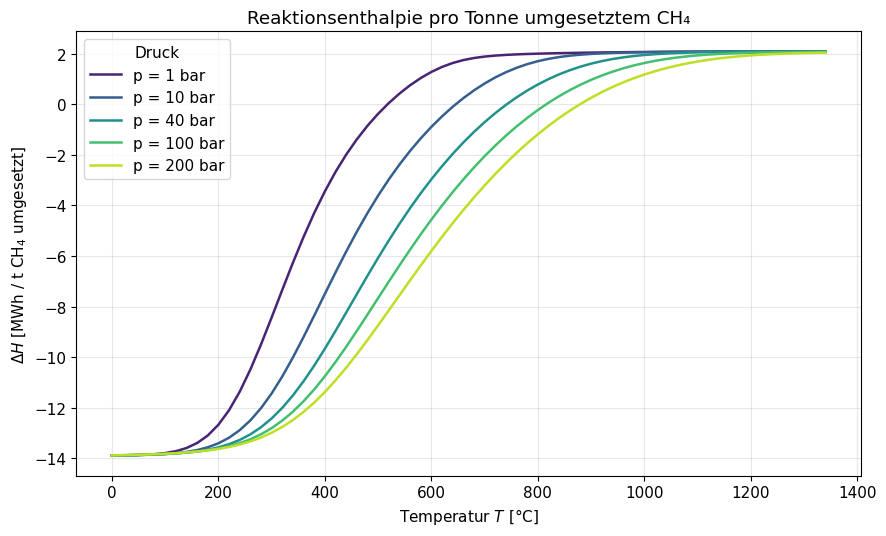

Plot gespeichert: Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf

Rest-p-Abhängigkeit (Spannweite max-min über alle Drücke je T):
  median: 1.6802 MWh/t
  max:    8.5041 MWh/t

ΔH [MWh / t CH₄ umgesetzt] — Statistik über den Druckbereich
 T [°C]  dH mean [MWh/t]  dH std  [MWh/t]  dH min  [MWh/t]  dH max  [MWh/t]
      0         -13.8943           0.0017         -13.8975         -13.8922
    100         -13.8308           0.0093         -13.8391         -13.8010
    200         -13.4955           0.2580         -13.6345         -12.6779
    300         -12.1445           1.2593         -12.9956          -8.4298
    400          -9.4527           2.3087         -11.3818          -3.4381
    500          -6.2323           2.5469          -8.7446          -0.3699
    600          -3.3637           2.2174          -5.8006           1.2849
    700          -1.1933           1.6738          -3.2066           1.8919
    800           0.2896           1.1076          -1.1816           2.0072
    90

In [44]:
# --- Reaktionsenthalpie pro Tonne UMGESETZTEM CH₄ ---
# Wiederverwendung der bereits berechneten Größen:
#   delta_H_mol [J / mol CH4 eingesetzt]  (aus Abschnitt 5)
#   Xconv       [-]  Umsatz               (aus Abschnitt 4)
#
# delta_H_mol / Xconv = J / mol CH4 umgesetzt   (mathematisch exakt)

M_CH4 = 0.01604  # kg/mol

# Division durch (fast) Null vermeiden
mask = Xconv > 1e-6
dH_MWh_per_t = np.full_like(delta_H_mol, np.nan)
dH_MWh_per_t[mask] = delta_H_mol[mask] / Xconv[mask] / M_CH4 * 1000.0 / 3.6e9
#                    └──── J/mol umges. ────┘ └─J/kg─┘ └kg/t┘ └J→MWh┘

print('Berechnung abgeschlossen ✓')
print(f'  Min ΔH: {np.nanmin(dH_MWh_per_t):7.3f} MWh / t CH₄ umgesetzt')
print(f'  Max ΔH: {np.nanmax(dH_MWh_per_t):7.3f} MWh / t CH₄ umgesetzt')

# --- Plot: ΔH(T) als Kurvenschar für ausgewählte Drücke ---
fig7, ax7 = plt.subplots(figsize=(9, 5.5))

p_show = [1, 10, 50, 100, 200]   # bar
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(p_show)))

for c, p_target in zip(colors, p_show):
    ip = int(np.argmin(np.abs(p_bar - p_target)))
    ax7.plot(T_C, dH_MWh_per_t[ip, :], color=c, lw=1.8,
             label=f'p = {p_bar[ip]:.0f} bar')

ax7.set_xlabel('Temperatur $T$ [°C]')
ax7.set_ylabel(r'$\Delta H$ [MWh / t CH$_4$ umgesetzt]')
ax7.set_title('Reaktionsenthalpie pro Tonne umgesetztem CH₄')
ax7.grid(alpha=0.3)
ax7.legend(title='Druck', loc='best')

plt.tight_layout()
fig7.savefig('Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf', dpi=150)
plt.show()
print('Plot gespeichert: Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf')

# --- Quantifizierung der Rest-p-Abhängigkeit ---
spread = np.nanmax(dH_MWh_per_t, axis=0) - np.nanmin(dH_MWh_per_t, axis=0)
print('\nRest-p-Abhängigkeit (Spannweite max-min über alle Drücke je T):')
print(f'  median: {np.nanmedian(spread):.4f} MWh/t')
print(f'  max:    {np.nanmax(spread):.4f} MWh/t')

# --- Tabelle: Statistik über p je T ---
df_T = pd.DataFrame({
    'T [°C]':           T_C.round(0).astype(int),
    'dH mean [MWh/t]':  np.nanmean(dH_MWh_per_t, axis=0).round(4),
    'dH std  [MWh/t]':  np.nanstd(dH_MWh_per_t,  axis=0).round(4),
    'dH min  [MWh/t]':  np.nanmin(dH_MWh_per_t,  axis=0).round(4),
    'dH max  [MWh/t]':  np.nanmax(dH_MWh_per_t,  axis=0).round(4),
})

print('\nΔH [MWh / t CH₄ umgesetzt] — Statistik über den Druckbereich')
print('=' * 72)
print(df_T.iloc[::5].to_string(index=False))

In [45]:
import cantera as ct
import numpy as np

M_CH4 = 0.01604  # kg/mol

g2 = ct.Solution('gri30.yaml')

query_points = [(850, 17), (1100, 51)]   # (T in °C, p in bar)

header = (f"{'T [°C]':>8}  {'p [bar]':>8}  {'X_CH4 [-]':>12}"
          f"  {'ΔH [kJ/mol CH4,ein]':>22}  {'ΔH [kJ/mol CH4,umg]':>22}")
print(header)
print("─" * 82)

for T_q, p_q in query_points:
    T_K   = T_q + 273.15
    p_Pa  = p_q * 1e5

    # ── Feed-Zustand ──────────────────────────────────────────────────────
    g2.TPX = T_K, p_Pa, X_dict
    w_CH4_feed = g2['CH4'].Y[0]
    h_ein      = g2.enthalpy_mass        # J/kg Feed

    # ── Gleichgewicht ─────────────────────────────────────────────────────
    g2.equilibrate('TP')
    w_CH4_eq = g2['CH4'].Y[0]
    h_aus    = g2.enthalpy_mass          # J/kg Produkt

    # ── Auswertung ────────────────────────────────────────────────────────
    X_val  = np.clip((w_CH4_feed - w_CH4_eq) / w_CH4_feed, 0.0, 1.0)
    dH_ein = (h_aus - h_ein) * M_CH4 / w_CH4_feed / 1e3   # kJ/mol CH4,ein
    dH_umg = dH_ein / X_val                                # kJ/mol CH4,umg

    print(f"{T_q:>8.0f}  {p_q:>8.0f}  {X_val:>12.4f}"
          f"  {dH_ein:>22.1f}  {dH_umg:>22.1f}")

  T [°C]   p [bar]     X_CH4 [-]     ΔH [kJ/mol CH4,ein]     ΔH [kJ/mol CH4,umg]
──────────────────────────────────────────────────────────────────────────────────
     850        17        0.8710                    87.8                   100.8
    1100        51        0.9771                   115.1                   117.8
